In [19]:
import numpy as np
import pandas as pd

In [20]:
df = pd.read_csv(r"C:\Users\ADYA TRIPATHI\OneDrive\Desktop\ML Projects\MicroGuard\smart_manufacturing_data.csv")

In [21]:
df.shape

(100000, 13)

In [22]:
df.head()

,timestamp,machine_id,temperature,vibration,humidity,pressure,energy_consumption,machine_status,anomaly_flag,predicted_remaining_life,failure_type,downtime_risk,maintenance_required
0,2025-01-01 00:00:00,39,78.61,28.65,79.96,3.73,2.16,1,0,106,Normal,0.0,0
1,2025-01-01 00:01:00,29,68.19,57.28,35.94,3.64,0.69,1,0,320,Normal,0.0,0
2,2025-01-01 00:02:00,15,98.94,50.20,72.06,1.00,2.49,1,1,19,Normal,1.0,1
3,2025-01-01 00:03:00,43,90.91,37.65,30.34,3.15,4.96,1,1,10,Normal,1.0,1
4,2025-01-01 00:04:00,8,72.32,40.69,56.71,2.68,0.63,2,0,65,Vibration Issue,0.0,1


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 13 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   timestamp                 100000 non-null  object 
 1   machine_id                100000 non-null  int64  
 2   temperature               100000 non-null  float64
 3   vibration                 100000 non-null  float64
 4   humidity                  100000 non-null  float64
 5   pressure                  100000 non-null  float64
 6   energy_consumption        100000 non-null  float64
 7   machine_status            100000 non-null  int64  
 8   anomaly_flag              100000 non-null  int64  
 9   predicted_remaining_life  100000 non-null  int64  
 10  failure_type              100000 non-null  object 
 11  downtime_risk             100000 non-null  float64
 12  maintenance_required      100000 non-null  int64  
dtypes: float64(6), int64(5), object(2)
memory usa

In [76]:
variances = np.var(df[['temperature','vibration','humidity','pressure',	'energy_consumption','machine_status','anomaly_flag','predicted_remaining_life','downtime_risk',	'maintenance_required']], axis=0)

for i, v in enumerate(variances):
    print(f"Feature {i}: Variance = {v}")

Feature 0: Variance = 100.63768825137524
Feature 1: Variance = 224.561272241097
Feature 2: Variance = 208.45259711887937
Feature 3: Variance = 1.3280104672181257
Feature 4: Variance = 1.6844360566655856
Feature 5: Variance = 0.1990857974999868
Feature 6: Variance = 0.081210494399933
Feature 7: Variance = 22518.697412894096
Feature 8: Variance = 0.08120207631295878
Feature 9: Variance = 0.1581728190996937


In [170]:
df['predicted_remaining_life'] = np.log1p(df['predicted_remaining_life'])

In [24]:
print(df['machine_status'].value_counts())
print(df['anomaly_flag'].value_counts())

machine_status
1    80091
2    10057
0     9852
Name: count, dtype: int64
anomaly_flag
0    91084
1     8916
Name: count, dtype: int64


In [25]:
print(df['failure_type'].value_counts())

failure_type
Normal              91899
Vibration Issue      3129
Overheating          1989
Pressure Drop        1969
Electrical Fault     1014
Name: count, dtype: int64


In [26]:
print(df.groupby('machine_status')[['anomaly_flag','downtime_risk','maintenance_required']].mean())		

                anomaly_flag  downtime_risk  maintenance_required
machine_status                                                   
0                   0.090438       0.090438              0.109216
1                   0.088662       0.088657              0.106928
2                   0.091876       0.091864              1.000000


In [27]:
print(df.groupby('machine_status')['predicted_remaining_life'].describe())	

                  count        mean         std  min   25%    50%    75%  \
machine_status                                                             
0                9852.0  234.548011  150.271367  1.0  96.0  232.0  366.0   
1               80091.0  234.380442  149.979427  1.0  97.0  230.0  365.0   
2               10057.0  233.109774  150.533903  1.0  94.0  230.0  365.0   

                  max  
machine_status         
0               499.0  
1               499.0  
2               499.0  


In [28]:
print(pd.crosstab(df['machine_status'], df['failure_type']))

failure_type    Electrical Fault  Normal  Overheating  Pressure Drop  \
machine_status                                                         
0                              0    9852            0              0   
1                              0   80091            0              0   
2                           1014    1956         1989           1969   

failure_type    Vibration Issue  
machine_status                   
0                             0  
1                             0  
2                          3129  


According to the data for machine status 
0 must be the running machines because has low anomaly rate and low downtime risk and lowest maintainence required ,these machines will be used to define the normal behaviour for our modelso that it can differentiate b/w normal and anomaly behaviour
1 must be the warning running machines because has low anomaly rate and low downtime risk and lowest maintainence required 
2 must be the machines which fail often because the crosstab shows a lot of values in every failure type

In [171]:
cols = ['temperature','vibration','humidity','pressure','energy_consumption','predicted_remaining_life']
df_core = df[cols] 

For anomaly detection the normal baehaviour will be used for training so that the maodel will take the normal data and learn its properties like mean and covariance and establish a normal behaviour boundary and when queried it can clearly flag the query 

In [173]:

contaminated = df.loc[(df['machine_status'] == 0) & (df['anomaly_flag'] == 1)]
print(len(contaminated), "anomalies are leaking in the 'normal' training set")

clean_normal = df[(df['machine_status'] == 0) & (df['anomaly_flag'] == 0)]

891 anomalies are leaking in the 'normal' training set


In [174]:
clean_normal

,timestamp,machine_id,temperature,vibration,humidity,pressure,energy_consumption,machine_status,anomaly_flag,predicted_remaining_life,failure_type,downtime_risk,maintenance_required,lifetime_log
9,2025-01-01 00:09:00,11,55.33,49.29,33.85,2.14,3.74,0,0,5.252273,Normal,0.0,0,5.252273
35,2025-01-01 00:35:00,47,70.49,59.54,65.34,3.10,1.88,0,0,6.056784,Normal,0.0,0,6.056784
40,2025-01-01 00:40:00,21,68.43,57.68,51.61,2.53,2.87,0,0,3.091042,Normal,0.0,0,3.091042
57,2025-01-01 00:57:00,47,67.14,45.96,31.58,1.29,3.17,0,0,5.480639,Normal,0.0,0,5.480639
59,2025-01-01 00:59:00,14,78.45,34.43,47.17,4.18,4.35,0,0,6.196444,Normal,0.0,0,6.196444
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99906,2025-03-11 09:06:00,36,65.39,55.20,60.48,3.21,3.02,0,0,2.833213,Normal,0.0,1,2.833213
99916,2025-03-11 09:16:00,20,60.88,60.76,47.39,4.36,2.14,0,0,5.192957,Normal,0.0,0,5.192957
99962,2025-03-11 10:02:00,13,80.20,52.95,48.12,2.01,1.31,0,0,3.583519,Normal,0.0,0,3.583519
99976,2025-03-11 10:16:00,31,67.74,36.55,48.56,1.22,1.73,0,0,3.784190,Normal,0.0,0,3.784190


In [175]:
# training sirf normal par 
X_train = clean_normal[cols].values

In [176]:
# testing sab par
X_test = df[cols].values
# model ki performance test krne ke liye
y_test = df['anomaly_flag'].values

In [177]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [190]:
from gaussian import fit, prob

mu, sigma = fit(X_train)
scores = prob(X_test, mu, sigma)

In [191]:
from sklearn.metrics import f1_score,precision_score,recall_score
best_epsilon = 0
best_f1 = 0

for eps in np.linspace(min(scores), max(scores), 1000):
    preds = (scores < eps)
    f1 = f1_score(y_test, preds)
    
    if f1 > best_f1:
        best_f1 = f1
        best_epsilon = eps

In [192]:
best_preds = (scores < best_epsilon)

In [193]:
print("Best Epsilon Value :",best_epsilon)
print("Best F1 Score :",best_f1)
print(precision_score(y_test,best_preds))
print(recall_score(y_test,best_preds))

Best Epsilon Value : 7.919867345848545e-06
Best F1 Score : 0.7480018096817976
0.6777808144301721
0.8344549125168237


In [194]:
from sklearn.metrics import confusion_matrix
preds = (scores < best_epsilon).astype(int)
print(confusion_matrix(y_test, preds))

[[87547  3537]
 [ 1476  7440]]


In [208]:
from gaussian import log_gaussian

log_scores = log_gaussian(X_test,mu,sigma)

In [209]:
best_log_eps = 0
best_log_f1 = 0

for eps in np.percentile(log_scores, np.linspace(0, 100, 1000)):
    log_preds = (log_scores < eps)
    f1 = f1_score(y_test, log_preds)
    
    if f1 > best_log_f1:
        best_log_f1 = f1
        best_log_eps = eps
        best_log_preds = (log_scores < best_log_eps)

In [210]:
print("Best Epsilon Value for log gaussian :",best_log_eps)
print("Best F1 Score for log gaussian:",best_log_f1)
print("Best Precision Score for log gaussian :",precision_score(y_test,best_log_preds))
print("Best Recall Score for log gaussian",recall_score(y_test,best_log_preds))

Best Epsilon Value for log gaussian : -11.629665132522561
Best F1 Score for log gaussian: 0.7496064541519087
Best Precision Score for log gaussian : 0.6676305643182615
Best Recall Score for log gaussian 0.854531179901301


In [211]:
from sklearn.metrics import confusion_matrix
preds = (log_scores < best_log_eps).astype(int)
print(confusion_matrix(y_test, best_log_preds))

[[87291  3793]
 [ 1297  7619]]


[[87291  3793]
 [ 1297  7619]]


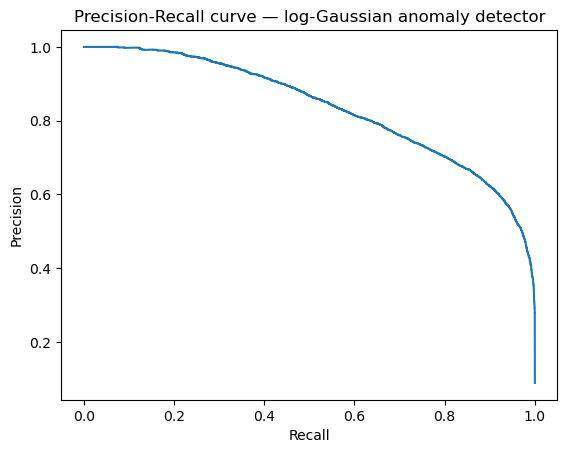

In [212]:
from sklearn.metrics import confusion_matrix, precision_recall_curve
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, best_log_preds)
print(cm)

precisions, recalls, _ = precision_recall_curve(y_test, -log_scores)
plt.plot(recalls, precisions)
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Precision-Recall curve — log-Gaussian anomaly detector")
plt.savefig("pr_curve.png")

In [213]:
np.savez(
    "model_params.npz",
    mu=mu,
    sigma=sigma,
    eps=best_log_eps,
    features=cols, 
    scaler_mean=scaler.mean_,  
    scaler_scale=scaler.scale_
)
 
print("Saved model_params.npz")

Saved model_params.npz
